In [1]:
from pathlib import Path
import re 
import ast
import sys, os
import glob
import csv
import pickle
sys.path.append(os.path.dirname(os.getcwd()))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import seaborn as sns
import statsmodels.api as sm
from functools import reduce 

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.title_fontsize'] = 12

from conf import config

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from nomad import accessibility
from nomad import utils

In [2]:
results = {}
solutions_folder = Path().absolute() / 'solutions_30min_v2'

for file in glob.glob(str(solutions_folder) + '/*.sol'):
    dev_pct = file[-11:-8]
    budget = file[-7:-4]
    with open(file, newline='\n') as csvfile:
        reader = csv.reader((line.replace('  ', ' ') for line in csvfile), delimiter=' ')
        first_row = next(reader)  # skip header
        second_row = next(reader)
        results[(dev_pct, budget)] = second_row[-1]

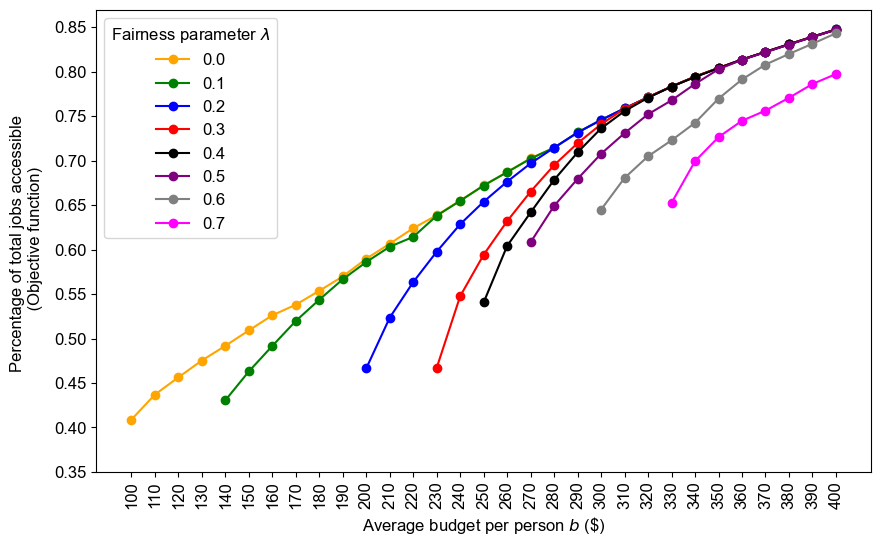

In [3]:
params = list(zip(*list(results.keys())))
dev_pct_list = list(params[0])
budget_list = list(params[1])
obj_val_list = list(results.values())

df = pd.DataFrame({'dev_pct': dev_pct_list, 'budget': budget_list, 'obj_val': obj_val_list} )
df['dev_pct'] = df['dev_pct'].astype(float)
df['budget'] = df['budget'].astype(int)
df['obj_val'] = df['obj_val'].astype(float)
df.sort_values(by=['dev_pct', 'budget'], inplace=True)

sorted_dev_pct = sorted(set(dev_pct_list))

cmap = dict(zip(sorted_dev_pct, ['orange','green','blue', 'red','black', 'purple', 'grey', 'magenta','maroon']))

fig, ax = plt.subplots(figsize=(10,6))

# Create an empty list for the legend handles and labels
handles = []
labels = []

# Plot each line in the sorted order for the correct display order in the legend
for i, d in enumerate(sorted_dev_pct):
    df_plot = df[df['dev_pct'] == float(d)].sort_values(by='budget')
    line, = ax.plot(df_plot['budget'], df_plot['obj_val'], marker='o', label=d, color=cmap[d])
    handles.append(line)  # Store the plot line as a handle
    labels.append(str(d))  # Store the label as a string

ax.set_xticks(df['budget'].unique())
ax.tick_params(axis='x', labelrotation=90)
ax.set_yticks(np.arange(0.35, 0.9, 0.05))
ax.tick_params(axis='y')

# Manually set the legend to ensure the labels are in the desired order (0.0 at the top)
ax.legend(handles=handles, labels=labels, title=r'Fairness parameter $\lambda$', loc='upper left')

ax.set_xlabel(r'Average budget per person $b$ (\$)', ha='center')
ax.set_ylabel('Percentage of total jobs accessible \n (Objective function)', va='center', rotation='vertical', labelpad=20)
plt.show();

#plt.setp(legend.get_title(), multialignment='center');

# fig, ax = plt.subplots()
# df_plot = df[df['budget'] == 360]
# ax.scatter(x = df_plot['dev_pct'], y = df_plot['obj_val'])
# ax.set_xlabel('Fairness parameter $\it{d}$')
# ax.set_ylabel('Percentage of total jobs accessible (Objective Function)', va='center', rotation='vertical');


In [4]:
import re
def get_results(solutions_folder, d, b):
    # Get the resuls of a single d and budget
    #params = {'dev_pct': d, 'budget_pp': b}
    # Define and solve model
    # model = define_model(params)
    # model = solve_model(model)
    #folder = Path().absolute() / 'solutions_30min'
    #filename = 'model_' + str(params['dev_pct']) + '_' + str(params['budget_pp']) 
    #filepath = str(folder / filename) + '.sol'
    A_dict = {}
    y_dict = {}
    z_dict = {}
    q_dict = {}
    u_dict = {}
    x_dict = {}

    filename = f"model_{d}_{b}.sol"
    filepath = os.path.join(solutions_folder, filename)
    
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('A'):
                var_name, var_value = line.strip().split()
                A_dict[int(re.findall(r'\d+', var_name)[0])] = float(var_value)
            if line.startswith('y'):
                var_name, var_value = line.strip().split()
                y_dict[int(re.findall(r'\d+', var_name)[0])] = float(var_value)
            if line.startswith('z'):
                var_name, var_value = line.strip().split()
                match = re.search(r'\[(\d+),(\d+)\]', var_name)
                if match:
                    result = tuple(map(int, match.groups()))
                    z_dict[result] = int(var_value)
            if line.startswith('q'):
                var_name, var_value = line.strip().split()
                match = re.search(r'\[(\d+),(\d+)\]', var_name)
                if match:
                    result = tuple(map(int, match.groups()))
                    q_dict[result] = int(var_value)
            if line.startswith('u'):
                var_name, var_value = line.strip().split()
                match = re.search(r'\[(\d+),(\d+),(\d+)\]', var_name)
                if match:
                    result = tuple(map(int, match.groups()))
                    u_dict[result] = int(var_value)
            if line.startswith('x'):
                var_name, var_value = line.strip().split()
                match = re.search(r'\[(\d+),(\d+),(\d+)\]', var_name)
                if match:
                    result = tuple(map(int, match.groups()))
                    x_dict[result] = int(var_value)     
                        
    return A_dict, y_dict, z_dict, q_dict, u_dict, x_dict

In [5]:
solutions_folder = Path().absolute() / 'solutions_30min_v2'
A_dict, y_dict, z_dict, q_dict, u_dict, x_dict = get_results(solutions_folder, d=0.5, b=270) # get_results(folder=Path().absolute() / 'solutions_30min', d=0.4, b=260)

In [6]:
cost_matrix_path = 'modal_travel_costs_2.csv'

org2idx = pd.read_csv('org2idx.csv')  #(solutions_folder / 'org2idx.csv')
dst2idx = pd.read_csv('dst2idx.csv')  #(solutions_folder / 'dst2idx.csv')

gdf_pop = gpd.read_file(config['paths']['data']['poverty_pop'])  
gdf_pop['GEOID'] = gdf_pop['GEOID'].astype(str)
gdf_pop['org_geo'] = gdf_pop['GEOID'].str[5:]
gdf_pop['org'] = 'org' + gdf_pop['org_geo']
gdf_pop['org_idx'] = gdf_pop['org'].map(dict(zip(org2idx['org_geo'], org2idx['org_idx'])))

gdf_jobs = gpd.read_file(config['paths']['data']['opp_jobs'])  #(conf.opp_jobs_path)
gdf_jobs.loc[gdf_jobs['opp_jobs_total'].isna(), 'opp_jobs_total'] = 0

gdf_jobs['GEOID'] = gdf_jobs['GEOID'].astype(str)
gdf_jobs['dst_geo'] = gdf_jobs['GEOID'].str[5:]
gdf_jobs['dst'] = 'dst' + gdf_jobs['dst_geo']

def calculate_expense_less_pt(row):
    if row['transit_included'] == True:
        if row['expense'] % 2.75 == 0:
            return 0
        else:
            return row['expense'] - 2.75
    else:
        return row['expense']

od_matrix = pd.read_csv(cost_matrix_path)

# For transfer trips, subtract 2.75. Solution below is a hack. Could fix properly when calc trip expense by checking node costs - but that takes a while
od_matrix['expense_less_pt'] = od_matrix.apply(calculate_expense_less_pt, axis=1)
od_matrix['access_indicator_time'] = (od_matrix['travel_time'] <= config['demographics']['TRAVEL_TIME_THRESHOLD']).astype(int) 
# Add job data
od_matrix = od_matrix.merge(gdf_jobs, how='left', on='dst')[['org', 'dst', 'mode_subset', 'travel_time', 'expense', 'expense_less_pt', 'gtc', 'opp_jobs_total', 'access_indicator_time']]
od_matrix['org_idx'] = od_matrix['org'].map(dict(zip(org2idx['org_geo'], org2idx['org_idx'])))
od_matrix['dst_idx'] = od_matrix['dst'].map(dict(zip(dst2idx['dst_geo'], dst2idx['dst_idx'])))
od_matrix.head()

,org,dst,mode_subset,travel_time,expense,expense_less_pt,gtc,opp_jobs_total,access_indicator_time,org_idx,dst_idx
0,org0103022,dst0103011,"('pt',)",196.948793,0.00,0.0,1.123790,13.802077,1,0,0
1,org0103022,dst0103022,"('pt',)",0.000000,0.00,0.0,0.026138,404.804941,1,0,1
2,org0103022,dst0305002,"('pt',)",207.376325,0.00,0.0,1.181918,18.631809,1,0,2
3,org0103022,dst0402001,"('pt',)",425.296474,0.00,0.0,2.397023,2.104510,1,0,3
4,org0103022,dst0402002,"('pt',)",1015.527696,2.75,0.0,9.406315,936.382504,1,0,4


In [7]:
#od_matrix_transit =  od_matrix.loc[od_matrix['mode_subset'] == "('pt',)"]
# filter out where gtc > 10000; indicates no feasible path
#od_matrix = od_matrix.copy()[od_matrix.copy()['gtc'] < 10000]

od_matrix['access_indicator_monetary'] = (od_matrix['expense_less_pt'] == 0).astype(int)
od_matrix['opportunities'] = od_matrix['opp_jobs_total'] * od_matrix['access_indicator_time'] * od_matrix['access_indicator_monetary']
cumulative_opps_no_sub = od_matrix.groupby(['org_idx','dst_idx'])['opportunities'].max().reset_index().groupby('org_idx')['opportunities'].sum().reset_index().sort_values(by='opportunities', ascending=True)
cumulative_opps_no_sub.sort_values(by='org_idx')

# Rename columns in cumulative_opps_no_sub
cumulative_opps_no_sub.rename(columns={'opportunities': 'transit_jobs'}, inplace=True)

,org_idx,opportunities
0,0,5799.977101
1,1,5001.060536
2,2,4876.200053
3,3,6825.777683
4,4,8423.728374
...,...,...
99,99,1371.003083
100,100,2364.316664
101,101,2482.884000
102,102,279.070772


In [8]:
# Create DataFrames from the model results
df_total_jobs = pd.DataFrame(A_dict.items(), columns=['org_idx', 'total_jobs']).sort_values(by='org_idx')
df_daily_allowance = pd.DataFrame(y_dict.items(), columns=['org_idx', 'daily_allowance']).sort_values(by='org_idx')

# Merge daily allowance and total jobs DataFrames
df_results = df_daily_allowance.merge(df_total_jobs, how='left', on='org_idx')

# Merge with pre-optimization transit access
df_results = df_results.merge(cumulative_opps_no_sub, how='left', on='org_idx')

# Calculate job difference and sort by transit jobs
df_results['job_diff'] = df_results['total_jobs'] - df_results['transit_jobs']
df_results.sort_values(by='transit_jobs', inplace=True)

# Map org_idx to org_geo
df_results['org_geo'] = df_results['org_idx'].map(dict(zip(org2idx['org_idx'], org2idx['org_geo'].str[3:])))

# Filter gdf_pop DataFrame
gdf_pop = gdf_pop[~gdf_pop['org_idx'].isna()]
gdf_pop_nonzero = gdf_pop[gdf_pop['total_eligible'] > 0]
gdf_pop_nonzero['org_idx'] = gdf_pop_nonzero['org_idx'].astype(int)

# Merge df_results with gdf_pop_nonzero
df_results = pd.merge(df_results, gdf_pop_nonzero[['geometry', 'org_idx', 'total_eligible']], how='inner', on='org_idx')

# Calculate population opportunity
df_results['pop_opp'] = df_results['total_eligible'] * df_results['total_jobs']

In [9]:
df_results[df_results['org_idx'] == 102]

,org_idx,daily_allowance,total_jobs,transit_jobs,job_diff,org_geo,geometry,total_eligible,pop_opp
1,102,12.286027,5237.412717,279.070772,4958.341946,5653001,"POLYGON ((-79.93726 40.39540, -79.93738 40.395...",169,885122.749213


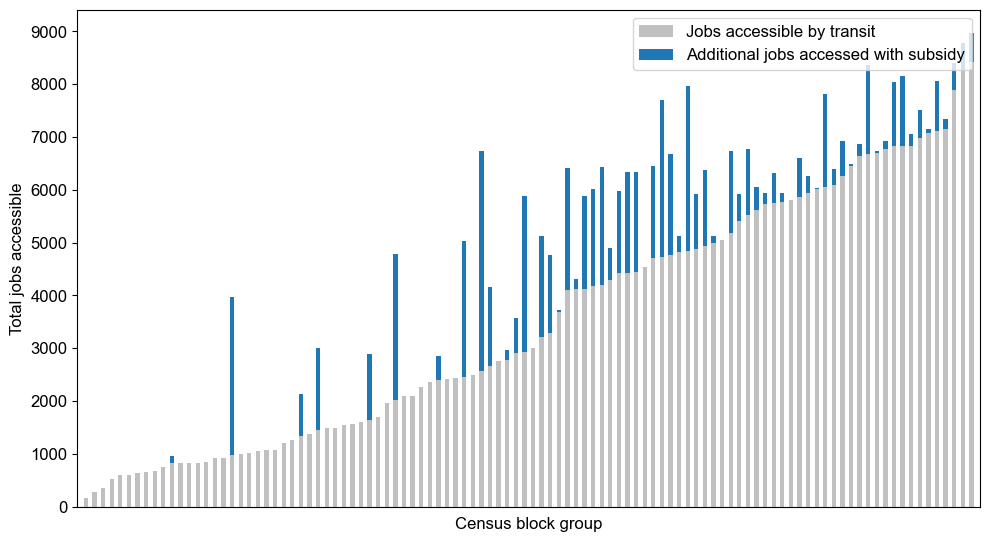

In [10]:
N = 40
b = 270
MONTHLY_TRANSIT_PASS = 97.50
b_star = b - MONTHLY_TRANSIT_PASS

# Copy the original DataFrame
df_equal = od_matrix.copy()

# Calculate access indicator for monetary expense
df_equal['access_indicator_monetary'] = (df_equal['expense_less_pt'].between(0, b_star / N, inclusive='both')).astype(int)

# Calculate opportunities
df_equal['opportunities'] = df_equal['opp_jobs_total'] * df_equal['access_indicator_time'] * df_equal['access_indicator_monetary']

# Group and sum opportunities
cumulative_opps_equal = df_equal.groupby(['org_idx', 'dst_idx'])['opportunities'].max().reset_index()
cumulative_opps_equal = cumulative_opps_equal.groupby('org_idx')['opportunities'].sum().reset_index().sort_values(by='opportunities', ascending=True)

# Merge with cumulative opportunities without subsidy
equal_subsidy = pd.merge(cumulative_opps_no_sub, cumulative_opps_equal, how='inner', on='org_idx')
equal_subsidy['job_diff'] = equal_subsidy['opportunities'] - equal_subsidy['transit_jobs']

# Filter gdf_pop DataFrame
gdf_pop = gdf_pop[~gdf_pop['org_idx'].isna()]
gdf_pop_nonzero = gdf_pop[gdf_pop['total_eligible'] > 0]
gdf_pop_nonzero['org_idx'] = gdf_pop_nonzero['org_idx'].astype(int)

# Merge with equal_subsidy DataFrame
equal_subsidy = pd.merge(equal_subsidy, gdf_pop_nonzero, how='inner', on='org_idx')
equal_subsidy['pop_opp'] = equal_subsidy['total_eligible'] * equal_subsidy['opportunities']

# Prepare data for plotting
weight_counts = {
    "Jobs accessible by transit": equal_subsidy['transit_jobs'],
    "Additional jobs accessed with subsidy": equal_subsidy['job_diff'],
}
width = 0.5

fig, ax = plt.subplots(figsize=(10, 6))
x = equal_subsidy['org_geo'].astype(str).tolist()
bottom = np.zeros(len(x))

cmap = {"Jobs accessible by transit": 'silver', "Additional jobs accessed with subsidy": 'tab:blue'}
for label, weight_count in weight_counts.items():
    ax.bar(x, weight_count, width, label=label, bottom=bottom, color=cmap[label])
    bottom += weight_count

# Customize plot
ax.legend(loc="upper right")
ax.set_xlabel('Census block group')
ax.set_ylabel('Total jobs accessible')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.set_yticks(np.arange(0, 10000, 1000))
ax.set_xlim(-1, len(x))
plt.tight_layout()
ax.set_xticks([])

plt.show();

In [11]:
df_results['pop_opp'] = df_results['total_eligible'] * df_results['total_jobs']

# Comparison:
equal_subsidy['pop_opp'].sum() / df_results['pop_opp'].sum()  # objective function
equal_subsidy['opportunities'].min() / equal_subsidy['opportunities'].max()  # level of fairness
# equal_subsidy['opportunities'].sum() / df_results['total_jobs'].sum()  

0.7850801100320164

0.018952272276496412

/home/lgraff/ENTER/envs/py39/lib/python3.9/site-packages/geopandas/tools/clip.py:67: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  clipped.loc[


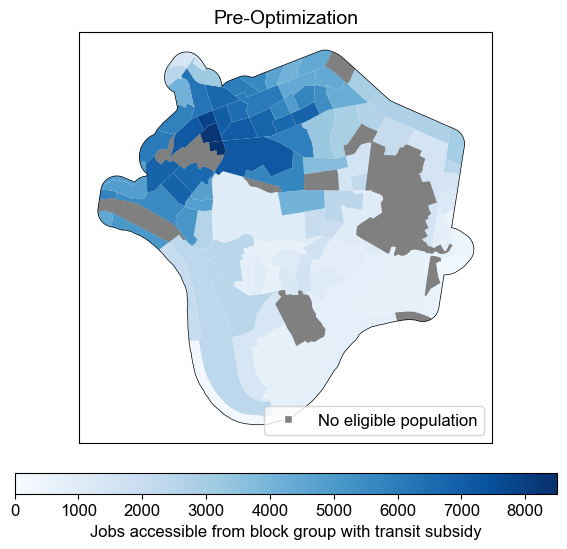

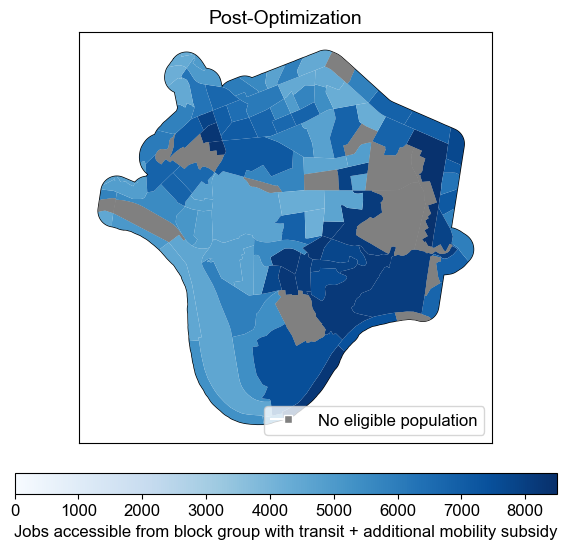

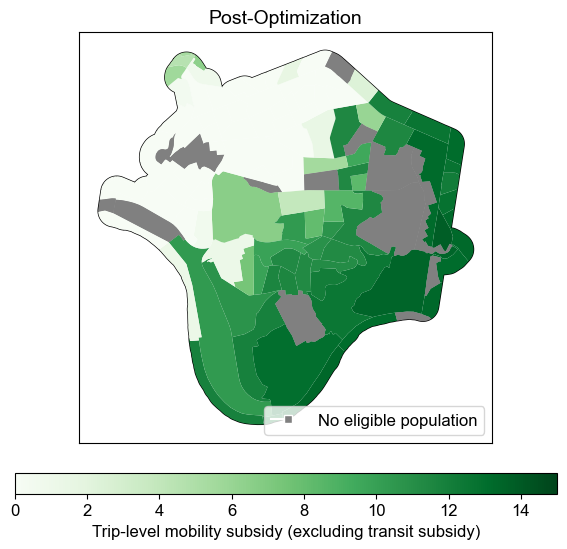

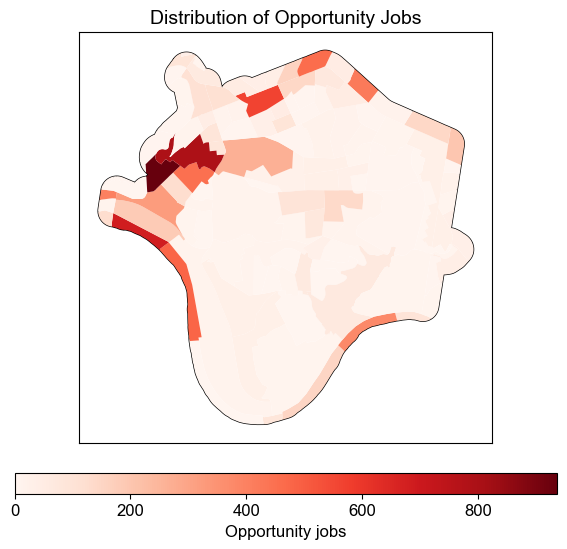

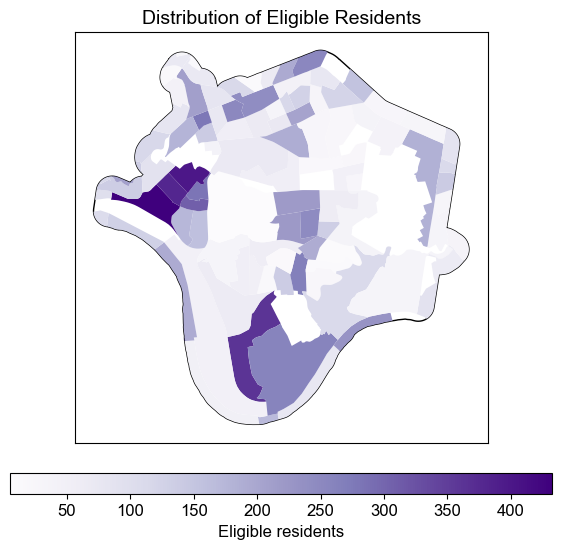

In [12]:
gdf_results = gpd.GeoDataFrame(df_results, geometry='geometry')

# Study area
study_area_gdf = gpd.read_file(config['paths']['data']['study_area_out'])  #(conf.study_area_outpath)
gdf_results = gpd.clip(gdf_results, study_area_gdf)

from mpl_toolkits.axes_grid1 import make_axes_locatable
org_centroids_gdf = gpd.read_file(config['paths']['data']['poverty_pop'])  #conf.subsidy_eligible_pop_path)
none_elig_gdf = org_centroids_gdf[org_centroids_gdf['total_eligible'] == 0]

# Pre-optimization
fig,ax = plt.subplots(figsize=(8,6))
divider = make_axes_locatable(ax)
cax = divider.append_axes('bottom', size='5%', pad=0.3)
none_elig_gdf.plot(ax=ax, color='gray')

study_area_gdf.plot(ax=ax, facecolor='none', edgecolor='black')
gdf_results.plot(ax=ax, column='transit_jobs', legend=True, vmin=0, vmax=8500, cax=cax, cmap='Blues',
                 legend_kwds={'label': 'Jobs accessible from block group with transit subsidy', 'orientation':'horizontal'})
none_elig_gdf.plot(ax=ax, color='gray')

legend_elements = [plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='gray', label='No eligible population')]
ax.legend(handles=legend_elements, loc='lower right')
ax.tick_params(labelsize=12)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Pre-Optimization')
plt.show();

# Post-optimization
fig,ax = plt.subplots(figsize=(8,6))
divider = make_axes_locatable(ax)
cax = divider.append_axes('bottom', size='5%', pad=0.3)

study_area_gdf.plot(ax=ax, facecolor='none', edgecolor='black')
none_elig_gdf.plot(ax=ax, color='gray')
gdf_results.plot(ax=ax, column='total_jobs', legend=True, vmin=0, vmax=8500, cax=cax, cmap='Blues',
                 legend_kwds={'label': 'Jobs accessible from block group with transit + additional mobility subsidy', 'orientation':'horizontal'})
none_elig_gdf.plot(ax=ax, color='gray')

legend_elements = [plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='gray', label='No eligible population')]
ax.legend(handles=legend_elements, loc='lower right')
ax.tick_params(labelsize=12)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Post-Optimization')
plt.show();

# Trip-level subsidy
fig,ax = plt.subplots(figsize=(8,6))
divider = make_axes_locatable(ax)
cax = divider.append_axes('bottom', size='5%', pad=0.3)
none_elig_gdf.plot(ax=ax, color='gray')

study_area_gdf.plot(ax=ax, facecolor='none', edgecolor='black')
gdf_results.plot(ax=ax, column='daily_allowance', legend=True, vmin=0, vmax=15, cax=cax, cmap='Greens',
                 legend_kwds={'label': 'Trip-level mobility subsidy (excluding transit subsidy)', 'orientation':'horizontal'})
none_elig_gdf.plot(ax=ax, color='gray')

legend_elements = [plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='gray', label='No eligible population')]
ax.legend(handles=legend_elements, loc='lower right')
ax.tick_params(labelsize=12)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Post-Optimization')
plt.show();

# Opportunity jobs
fig,ax = plt.subplots(figsize=(8,6))
divider = make_axes_locatable(ax)
cax = divider.append_axes('bottom', size='5%', pad=0.3)
study_area_gdf.plot(ax=ax, facecolor='none', edgecolor='black')
gdf_jobs.plot(ax=ax, column='opp_jobs_total', cmap='Reds', legend=True, cax=cax,
              legend_kwds={'label': 'Opportunity jobs', 'orientation':'horizontal'})
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Distribution of Opportunity Jobs')
plt.show();

# Eligible population
fig,ax = plt.subplots(figsize=(8,6))
divider = make_axes_locatable(ax)
cax = divider.append_axes('bottom', size='5%', pad=0.3)
study_area_gdf.plot(ax=ax, facecolor='none', edgecolor='black')
gdf_pop.plot(ax=ax, column='total_eligible', cmap='Purples', legend=True, cax=cax,
              legend_kwds={'label': 'Eligible residents', 'orientation':'horizontal'})
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Distribution of Eligible Residents')
plt.show();

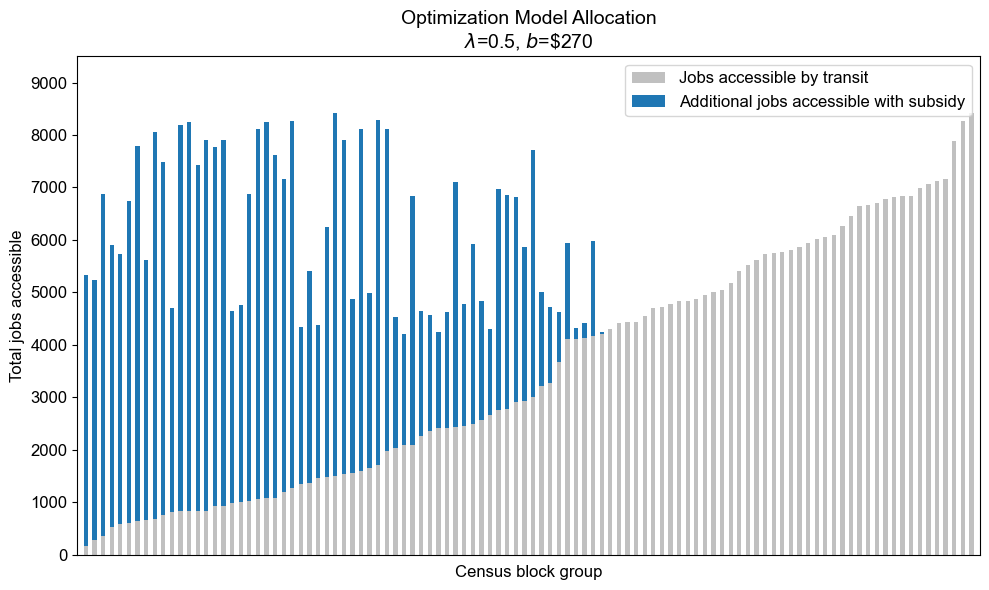

In [20]:
import numpy as np
import matplotlib.pyplot as plt
weight_counts = {
    "Jobs accessible by transit": df_results['transit_jobs'],
    "Additional jobs accessible with subsidy": df_results['job_diff'],
}
width = 0.5

fig, ax = plt.subplots(figsize=(10,6))
x = df_results['org_geo'].astype(str).tolist()
bottom = np.zeros(len(x))

cmap = {"Jobs accessible by transit": 'silver', "Additional jobs accessible with subsidy": 'tab:blue'}
for boolean, weight_count in weight_counts.items():
    p = ax.bar(x, weight_count, width, label=boolean, bottom=bottom, color=cmap[boolean])
    bottom += weight_count

ax.set_title(r"Optimization Model Allocation" "\n" "$\lambda$=0.5, $b$=\$270")
ax.legend(loc="upper right")
ax.set_xlabel('Census block group') # FIPS code (tract + block group)')
ax.set_ylabel('Total jobs accessible')
# ax.set_xticks(x)
# ax.tick_params(axis='x', labelrotation=90, labelsize=8)

ax.set_xticks([])
yticks = np.arange(0,10000,1000)
ax.set_yticks(yticks)

# highlight = ['1414001', '1516001']
# for label in ax.get_xticklabels():
#     if label.get_text() in highlight:
#         label.set_color('red')
#     else:
#         label.set_color('black')

bbox = dict(boxstyle='round,pad=0.5', edgecolor='black', facecolor='lightyellow')
arrowprops=dict(facecolor='black', arrowstyle='->', lw=2)
# ax.annotate(text='Block group\n 1414004', xy=(11,8250), xytext=(11,9450), color='red', ha='center', va='center', fontsize=12, bbox=bbox, arrowprops=arrowprops)
# ax.annotate(text='Block group\n 1516001', xy=(10,4800), xytext=(10,6000), color='red', ha='center', va='center', fontsize=12, bbox=bbox, arrowprops=arrowprops)
ax.set_xlim(-1, len(x))
ax.set_ylim(ymin=0, ymax=9500)
plt.tight_layout()
plt.show();

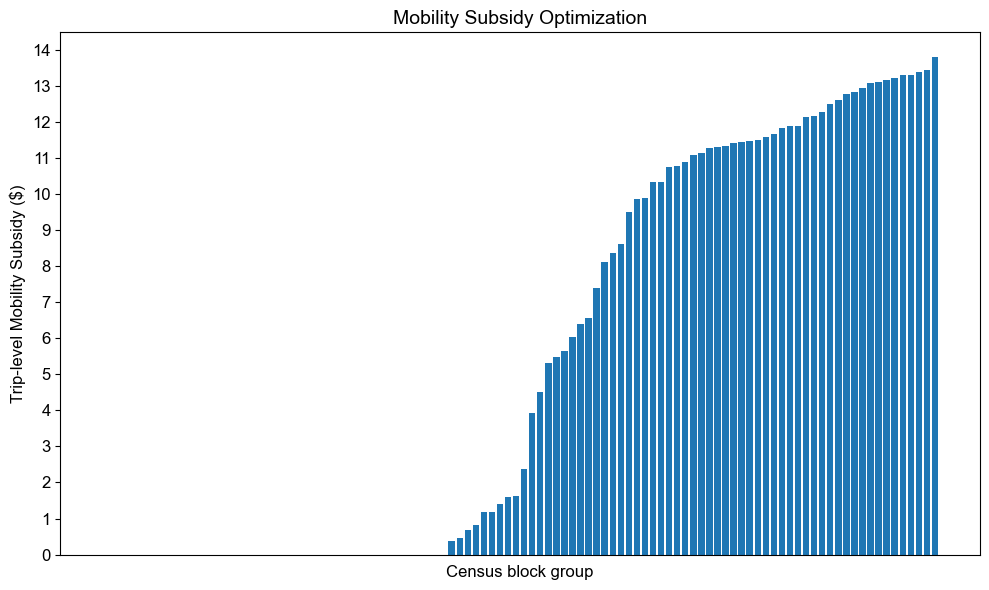

In [14]:
import numpy as np
import matplotlib.pyplot as plt
weight_counts = {
    "Jobs accessible by transit": df_results['transit_jobs'],
    "Additional jobs accessible with subsidy": df_results['job_diff'],
}
width = 0.5

fig, ax = plt.subplots(figsize=(10,6))
df_results.sort_values(by='daily_allowance', inplace=True)
x = df_results['org_geo'].astype(str).tolist()

# cmap = {"Jobs accessible by transit": 'silver', "Additional jobs accessible with subsidy": 'tab:blue'}
# for boolean, weight_count in weight_counts.items():
#     p = ax.bar(x, weight_count, width, label=boolean, bottom=bottom, color=cmap[boolean])
#     bottom += weight_count


ax.bar(df_results['org_geo'].astype(str).tolist(), df_results['daily_allowance'])
ax.set_title("Mobility Subsidy Optimization") # \n $\it{d}$=0.4, $\it{b}$=\$260")
# ax.legend(loc="upper right")
ax.set_xlabel('Census block group') # FIPS code (tract + block group)')
ax.set_ylabel('Trip-level Mobility Subsidy ($)')
# ax.tick_params(axis='x', labelrotation=90, labelsize=8)
yticks = np.arange(0,15,1)
ax.set_yticks(yticks)
ax.set_xticks([])
# highlight = ['1414001', '1517002']
# for label in ax.get_xticklabels():
#     if label.get_text() in highlight:
#         label.set_color('red')
#     else:
#         label.set_color('black')

# bbox = dict(boxstyle='round,pad=0.5', edgecolor='black', facecolor='lightyellow')
# arrowprops=dict(facecolor='black', arrowstyle='->', lw=2)
# #ax.annotate(text='Block group\n 1414001', xy=(11,8450), xytext=(11,9450), color='red', ha='center', va='center', fontsize=12, bbox=bbox, arrowprops=arrowprops)
# #ax.annotate(text='Block group\n 1517002', xy=(16,3700), xytext=(16,4700), color='red', ha='center', va='center', fontsize=12, bbox=bbox, arrowprops=arrowprops)
# ax.set_xticklabels([]) #(x, fontsize=8)
# ax.set_xlim(-1, len(x))
# ax.set_ylim(ymin=0, ymax=9500)
plt.tight_layout()
plt.show();

In [15]:
bins = [-float('inf'), 3, 10, float('inf')]
labels = [0, 1, 2]
df_results['group'] = pd.cut(df_results['daily_allowance'], bins=bins, labels=labels, right=True)
df_results.head()

graphs_folder = Path().parent.absolute().resolve() / 'graphs'
# Read in the supernetwork as an object
with open(graphs_folder / 'graph_sn.pkl', 'rb') as inp:
    G_sn = pickle.load(inp)

org_bs_cnx_edges = [e for e in G_sn.graph.edges if e[0].startswith('org') and e[1].startswith('bs')]
org_transit_cnx_edges = [e for e in G_sn.graph.edges if e[0].startswith('org') and e[1].startswith('ps')]

,org_idx,daily_allowance,total_jobs,transit_jobs,job_diff,org_geo,geometry,total_eligible,pop_opp,group
103,4,0.0,8423.728374,8423.728374,-1.818989e-12,0404001,"POLYGON ((-79.95028 40.44682, -79.94989 40.446...",41,345372.863321,0
79,47,0.0,5734.503622,5734.503622,-2.728484e-12,1401002,"POLYGON ((-79.94202 40.44069, -79.94186 40.441...",55,315397.699216,0
78,39,0.0,5609.933947,5609.933947,0.000000e+00,0806002,"POLYGON ((-79.93687 40.45946, -79.93674 40.459...",15,84149.009199,0
76,26,0.0,5415.148374,5415.148374,0.000000e+00,0706001,"POLYGON ((-79.92535 40.45450, -79.92534 40.454...",31,167869.599591,0
75,11,0.0,5177.015286,5177.015286,0.000000e+00,0409002,"POLYGON ((-79.95848 40.43260, -79.95845 40.432...",174,900800.659726,0


In [16]:
# how many unique bikeshare stations, physical stops are connected to each origin
# Initialize counters
org_bs_dict = dict(zip(df_results['org_geo'], np.zeros(len(df_results)))) 
org_transit_dict = dict(zip(df_results['org_geo'], np.zeros(len(df_results)))) 

for edge in org_bs_cnx_edges:
    geo = edge[0][3:]
    org_bs_dict[geo] += 1

org_transit_stops = dict(zip(df_results['org_geo'], []*len(df_results)))
for edge in org_transit_cnx_edges:
    geo = edge[0][3:]
    org_transit_dict[geo] += 1

data_path = config['paths']['data']
GTFS_path = data_path['GTFS']
stop_times = pd.read_csv(Path(GTFS_path) / 'stop_times.txt')
trips = pd.read_csv(Path(GTFS_path) / 'trips.txt')
routes = pd.read_csv(Path(GTFS_path) / 'routes.txt')

/tmp/ipykernel_16978/1447602848.py:17: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(Path(GTFS_path) / 'stop_times.txt')


<AxesSubplot: >

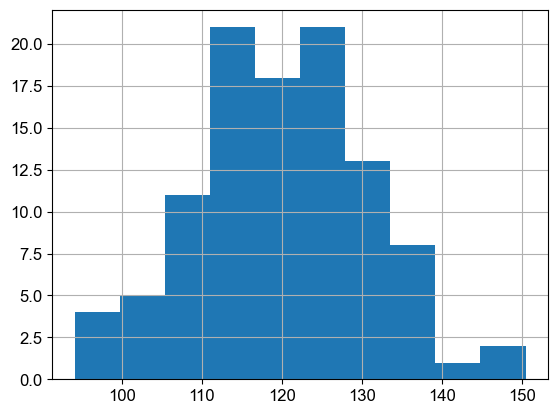

In [17]:
org_sc_dict = dict(zip(df_results['org_geo'], np.zeros(len(df_results)))) 

org_sc_cnx_edges = [e for e in G_sn.graph.edges if e[0].startswith('org') and e[1].startswith('sc')]
for edge in org_sc_cnx_edges:
    org = edge[0]
    length = G_sn.graph.edges[edge]['length_m']
    org_sc_dict[org[3:]] = length

org_sc_df = pd.DataFrame(list(org_sc_dict.items()), columns=['org_geo', 'length_scooter'])
org_sc_df['length_scooter'].hist()

In [17]:
org_transit = {}
start_time, end_time = "07:00:00", "09:00:00"
for org in df_results['org_geo']:
    transit_info = {}
    # Get all tuples whose first value is org
    stop_group = [edge[1][2:] for edge in org_transit_cnx_edges if edge[0][3:] == org]
    # Filter stop_times by start/end time and stop_group
    filtered_stop_times = stop_times[((stop_times['stop_id'].isin(stop_group)) & (stop_times['arrival_time'] >= start_time) & (stop_times['arrival_time'] <= end_time))]
    # Get number of unique bus runs
    unique_trips = filtered_stop_times['trip_id'].unique()
    num_unique_bus_runs = len(unique_trips)
    transit_info['runs'] = num_unique_bus_runs
    # Get the number of unique routes
    stop_times_trips = pd.merge(filtered_stop_times, trips, on='trip_id', how='inner')
    stop_times_trips_routes = pd.merge(stop_times_trips, routes, on='route_id', how='inner')
    unique_routes = stop_times_trips_routes['route_id'].unique()
    num_unique_routes = len(unique_routes)
    transit_info['routes'] = num_unique_routes

    bus_runs_per_route = stop_times_trips_routes.groupby('route_id')['trip_id'].nunique()
    total_bus_runs = bus_runs_per_route.sum()
    num_unique_routes = bus_runs_per_route.shape[0]
    avg_runs_per_route = total_bus_runs / num_unique_routes
    num_short_headway_routes = (120 / bus_runs_per_route / 2 < 15).sum()  # avg_headway (from 7-9am) / 2 (approx waiting time)

    transit_info['avg_runs_per_route'] = avg_runs_per_route
    transit_info['num_short_headway_routes'] = num_short_headway_routes
    org_transit[org] = transit_info

records = [{'org_geo':org, **values} for org, values in org_transit.items()]
org_transit_df = pd.DataFrame(records)

/tmp/ipykernel_16978/4259843365.py:23: RuntimeWarning: invalid value encountered in long_scalars
  avg_runs_per_route = total_bus_runs / num_unique_routes
/tmp/ipykernel_16978/4259843365.py:23: RuntimeWarning: invalid value encountered in long_scalars
  avg_runs_per_route = total_bus_runs / num_unique_routes
/tmp/ipykernel_16978/4259843365.py:23: RuntimeWarning: invalid value encountered in long_scalars
  avg_runs_per_route = total_bus_runs / num_unique_routes
/tmp/ipykernel_16978/4259843365.py:23: RuntimeWarning: invalid value encountered in long_scalars
  avg_runs_per_route = total_bus_runs / num_unique_routes
/tmp/ipykernel_16978/4259843365.py:23: RuntimeWarning: invalid value encountered in long_scalars
  avg_runs_per_route = total_bus_runs / num_unique_routes


In [18]:
bus_runs_per_route = stop_times_trips_routes.groupby('route_id')['trip_id'].nunique()
bus_runs_per_route
total_bus_runs = bus_runs_per_route.sum()
num_unique_routes = bus_runs_per_route.shape[0]
avg_runs_per_route = total_bus_runs / num_unique_routes
avg_runs_per_route

route_id
61B    7
P71    1
Name: trip_id, dtype: int64

4.0

In [19]:
org_centroids_gdf = gpd.read_file(data_path['poverty_pop'])
org_centroids_eligible = org_centroids_gdf[org_centroids_gdf['total_eligible'] > 0].reset_index(drop=True)  # only the origins with eligible pop.
org_centroids_eligible['org_geo'] = org_centroids_eligible['GEOID'].str[5:]
dst_centroids_gdf = gpd.read_file(data_path['opp_jobs'])
dst_centroids_gdf = dst_centroids_gdf[dst_centroids_gdf['opp_jobs_total'] > 0].reset_index(drop=True)       # only the destinations with opp job total > 0
dst_centroids_gdf['dst_geo'] = dst_centroids_gdf['GEOID'].str[5:]

org_coords = org_centroids_eligible[['x','y']].to_numpy()  # convert org centroids to numpy array
dst_coords = dst_centroids_gdf[['x','y']].to_numpy()  # convert dst centroids to numpy array

org_jobs_by_dist = org_centroids_eligible[['org_geo']].copy()

od_dist_matrix = np.zeros((len(org_coords), len(dst_coords)))
for i in range(len(org_coords)):
    od_dist_matrix[i,:] = utils.calc_great_circle_dist(np.array(org_coords)[i], np.array(dst_coords))  # meters

CIRCUITY_FACTOR = 1.2
od_dist_matrix = od_dist_matrix * CIRCUITY_FACTOR  # account for difference between network and euclidean distance

dst_jobs = np.repeat(dst_centroids_gdf['opp_jobs_total'].values.reshape(1,-1), repeats=len(od_dist_matrix), axis=0)

MILE_TO_METERS = 1609

def count_jobs_by_dist(od_dist_matrix, lower_bound, upper_bound):
    condition = (((od_dist_matrix / MILE_TO_METERS) > lower_bound) & ((od_dist_matrix / MILE_TO_METERS) <= upper_bound)).astype(int) # where network distance is less than 1 mile
    job_count = np.sum(dst_jobs * condition, 1)
    return job_count

org_jobs_by_dist['less_than_1'] = count_jobs_by_dist(od_dist_matrix, -1, 1) / 100
org_jobs_by_dist['between_1_2'] = count_jobs_by_dist(od_dist_matrix, 1, 2) / 100
org_jobs_by_dist['above_2'] = count_jobs_by_dist(od_dist_matrix, 2, float(np.inf)) / 100

In [21]:
org_unique_bus_runs_df = pd.DataFrame(list(org_bs_dict.items()), columns=['org_geo', 'num_unique_bus_runs'])
org_bs_df = pd.DataFrame(list(org_bs_dict.items()), columns=['org_geo', 'count_bikeshare'])
org_bs_df['has_bikeshare'] = np.where(org_bs_df['count_bikeshare'] > 0, 1, 0)
#org_transit_df = pd.DataFrame(list(org_transit_dict.items()), columns=['org_geo', 'count_transit_stops'])

dfs = [df_results, org_bs_df, org_transit_df, org_jobs_by_dist]
df_merge = reduce(lambda left, right: pd.merge(left,right, on='org_geo', how='left'), dfs)
#df_merge['avg_runs_per_route'] = df_merge['runs'] / df_merge['routes']
df_merge['avg_runs_per_route'] = df_merge['avg_runs_per_route'].fillna(0)
df_merge['avg_headway'] = 120 / df_merge['runs']
df_merge['avg_headway'].replace(np.inf, 120, inplace=True)

covariates = ['total_eligible', 'runs', 'has_bikeshare', 'less_than_1', 'between_1_2']
X = df_merge[covariates]
y = df_merge['daily_allowance']
X = sm.add_constant(X)
model = sm.OLS(y,X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        daily_allowance   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     115.1
Date:                Sat, 28 Dec 2024   Prob (F-statistic):           2.01e-39
Time:                        15:56:47   Log-Likelihood:                -224.74
No. Observations:                 104   AIC:                             461.5
Df Residuals:                      98   BIC:                             477.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             15.0316      0.658     22.

In [28]:
df_merge.head()

,org_idx,daily_allowance,total_jobs,transit_jobs,job_diff,org_geo,geometry,total_eligible,pop_opp,group,...,has_bikeshare,runs,routes,avg_runs_per_route,num_short_headway_routes,less_than_1,between_1_2,above_2,avg_headway,pred
0,4,0.0,8423.728374,8423.728374,-1.818989e-12,0404001,"POLYGON ((-79.95028 40.44682, -79.94989 40.446...",41,345372.863321,0,...,1,39,16,2.4375,2,37.627885,34.444519,27.861608,3.076923,0.000000
1,47,0.0,5734.503622,5734.503622,-2.728484e-12,1401002,"POLYGON ((-79.94202 40.44069, -79.94186 40.441...",55,315397.699216,0,...,0,33,11,3.0000,2,8.431218,56.568851,34.933944,3.636364,3.049203
2,39,0.0,5609.933947,5609.933947,0.000000e+00,0806002,"POLYGON ((-79.93687 40.45946, -79.93674 40.459...",15,84149.009199,0,...,1,30,12,2.5000,1,20.602278,27.200089,52.131645,4.000000,2.225499
3,26,0.0,5415.148374,5415.148374,0.000000e+00,0706001,"POLYGON ((-79.92535 40.45450, -79.92534 40.454...",31,167869.599591,0,...,1,45,16,2.8125,2,22.745163,15.578167,61.610682,2.666667,2.555362
4,11,0.0,5177.015286,5177.015286,0.000000e+00,0409002,"POLYGON ((-79.95848 40.43260, -79.95845 40.432...",174,900800.659726,0,...,1,12,5,2.4000,1,27.550196,30.502583,41.881232,10.000000,1.135820


In [22]:
# Generate predicted values
df_merge['pred'] = model.predict(X).clip(lower=0)
df_pred = od_matrix.copy()

df_pred = pd.merge(df_pred.drop(['access_indicator_monetary'], axis=1), df_merge[['org_idx', 'pred']], on='org_idx', how='left')

# # Adjustments for testing
# df_pred.loc[df_pred['org'] == 'org1517002', 'pred'] = 8.32 + 2
# df_pred.loc[df_pred['org'] == 'org1413002', 'pred'] = 7.015682 + 2

df_pred['access_indicator_monetary'] = (df_pred['expense_less_pt'] <= df_pred['pred']).astype(int)
df_pred['opportunities'] = df_pred['opp_jobs_total'] * df_pred['access_indicator_time'] * df_pred['access_indicator_monetary']
cumulative_opps_pred = df_pred.groupby(['org_idx','dst_idx'])['opportunities'].max().reset_index().groupby('org_idx')['opportunities'].sum().reset_index().sort_values(by='opportunities', ascending=True)
pred_subsidy = pd.merge(cumulative_opps_no_sub, cumulative_opps_pred, how='inner', on='org_idx')
pred_subsidy['job_diff'] = pred_subsidy['opportunities'] - pred_subsidy['transit_jobs']

gdf_pop = gdf_pop[~gdf_pop['org_idx'].isna()]
gdf_pop_nonzero = gdf_pop[gdf_pop['total_eligible'] > 0]
gdf_pop_nonzero['org_idx'] = gdf_pop_nonzero['org_idx'].astype(int)
pred_subsidy = pd.merge(pred_subsidy, gdf_pop_nonzero, how='inner', on='org_idx')
pred_subsidy['pop_opp'] = pred_subsidy['total_eligible'] * pred_subsidy['opportunities']

# Comparison
pred_subsidy['pop_opp'] = pred_subsidy['total_eligible'] * pred_subsidy['opportunities']
print('objective function relative to optimal case')
pred_subsidy['pop_opp'].sum() / df_results['pop_opp'].sum()  # objective function
print('level of fairness')
pred_subsidy['opportunities'].min() / pred_subsidy['opportunities'].max() # fairness

objective function relative to optimal case


0.8967395890667198

level of fairness


0.11413635487115383

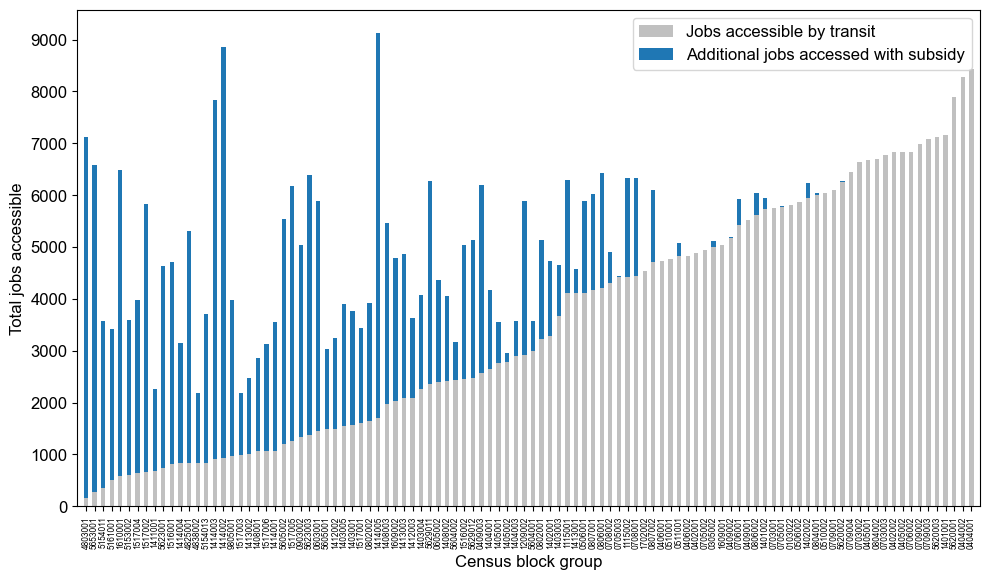

In [52]:
weight_counts = {
    "Jobs accessible by transit": pred_subsidy['transit_jobs'],
    "Additional jobs accessed with subsidy": pred_subsidy['job_diff'],
}
width = 0.5

fig, ax = plt.subplots(figsize=(10,6))
x = pred_subsidy['org_geo'].astype(str).tolist()
bottom = np.zeros(len(x))

cmap = {"Jobs accessible by transit": 'silver', "Additional jobs accessed with subsidy": 'tab:blue'}
for boolean, weight_count in weight_counts.items():
    p = ax.bar(x, weight_count, width, label=boolean, bottom=bottom, color=cmap[boolean])
    bottom += weight_count

#ax.set_title("Equal Subsidy Allocation")
ax.legend(loc="upper right")
ax.set_xlabel('Census block group')
ax.set_ylabel('Total jobs accessible')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
yticks = np.arange(0,10000,1000)
ax.set_yticks(yticks)
ax.set_xlim(-1, len(x))
plt.tight_layout()
ax.set_xticks([])
ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, fontsize=6)
plt.show();

<AxesSubplot: >

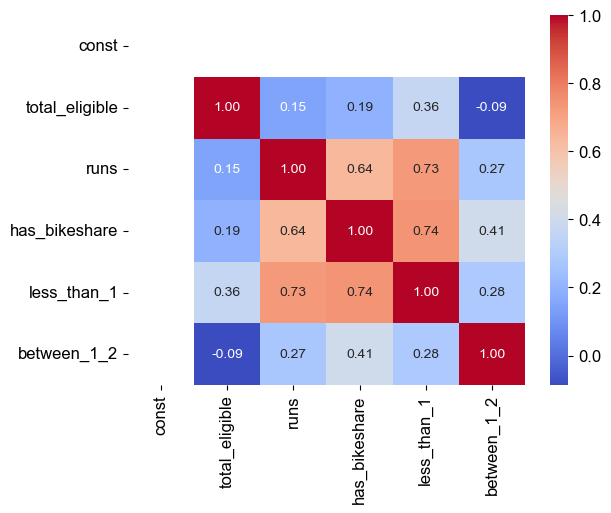

In [33]:
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

<Figure size 800x500 with 0 Axes>

<AxesSubplot: xlabel='group', ylabel='count_transit_stops'>

<Figure size 800x500 with 0 Axes>

<AxesSubplot: xlabel='group', ylabel='count_bikeshare'>

<Figure size 800x500 with 0 Axes>

<AxesSubplot: xlabel='group', ylabel='less_than_1'>

<Figure size 800x500 with 0 Axes>

<AxesSubplot: xlabel='group', ylabel='between_1_2'>

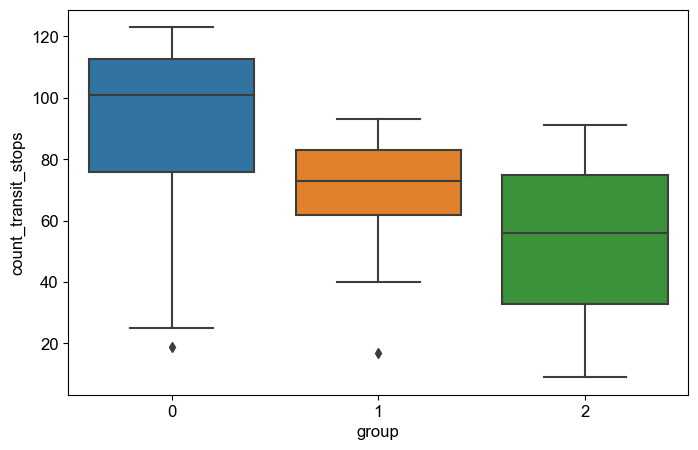

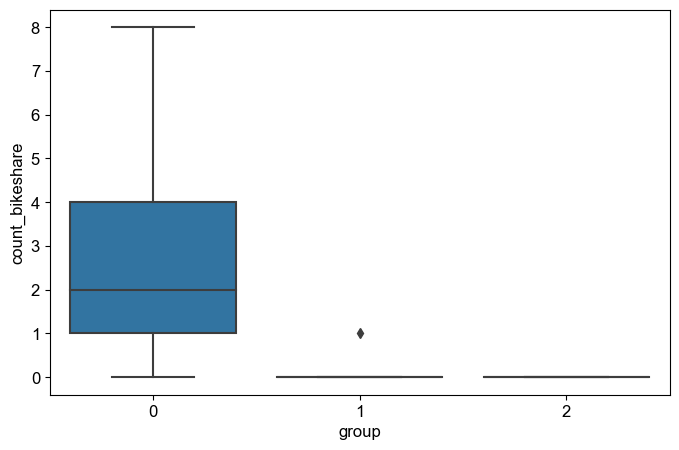

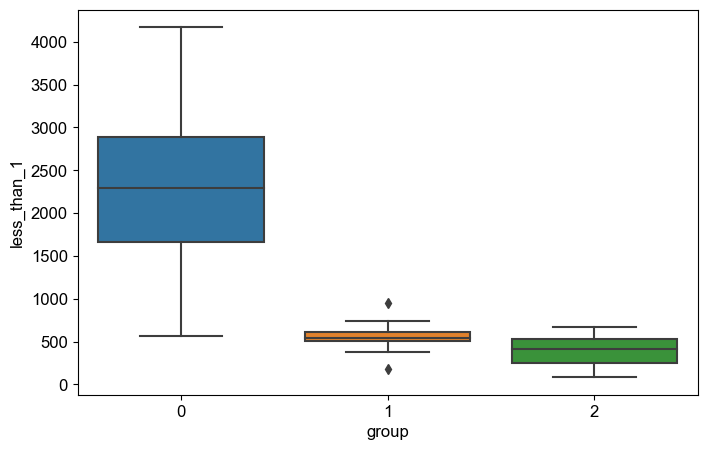

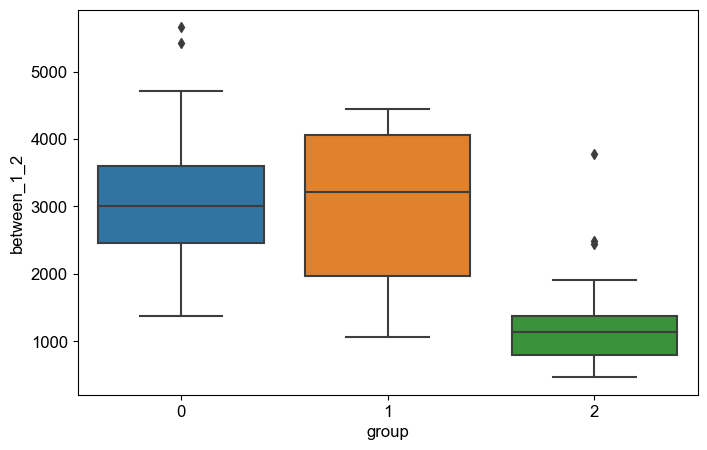

In [221]:
for cov in covariates:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='group', y=cov, data=df_merge)

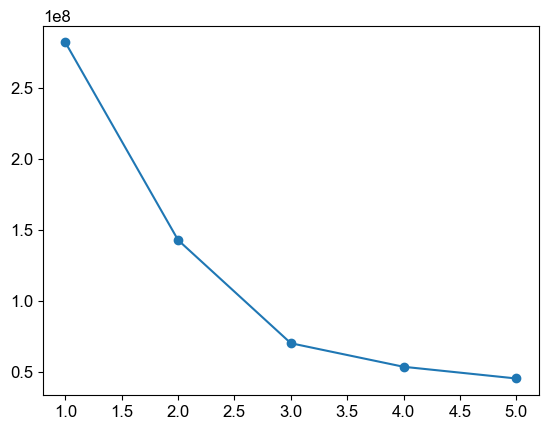

In [235]:
wcss = []
from sklearn.cluster import KMeans
for i in range(1,6):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init='auto').fit(df_merge[covariates + ['daily_allowance']])
    wcss.append(kmeans.inertia_)
plt.plot(range(1,6), wcss, marker='o')

# choose 3 clusters
kmeans_3 = KMeans(n_clusters=3, random_state=0, n_init='auto').fit(df_merge[covariates + ['daily_allowance']])
cluster_assignments = kmeans_3.labels_
df_merge['kmeans_cluster'] = cluster_assignments

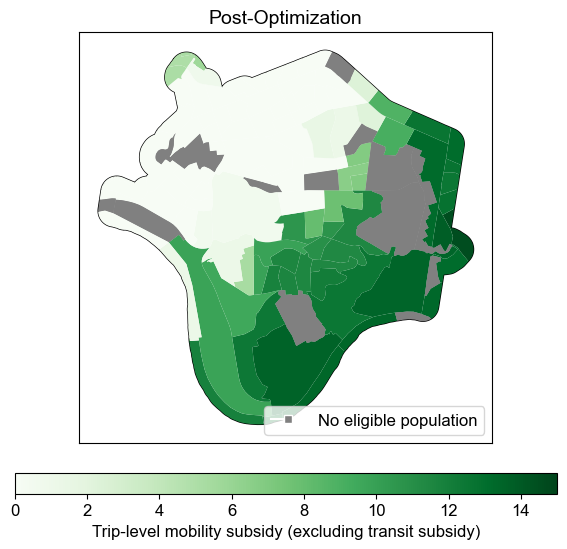

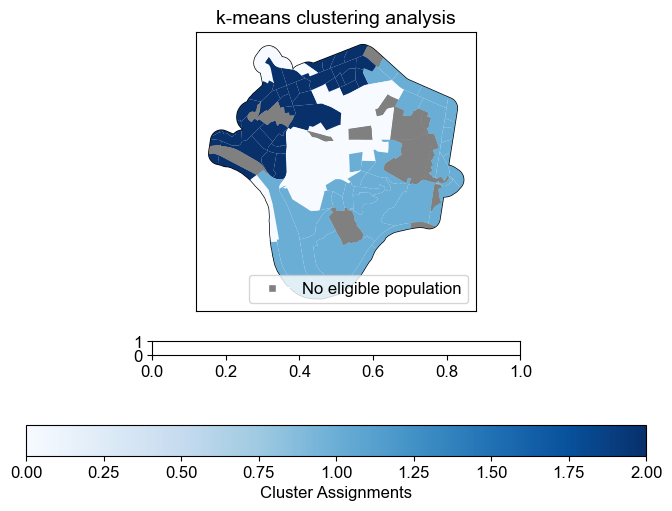

In [237]:
# Trip-level subsidy
fig,ax = plt.subplots(figsize=(8,6))
divider = make_axes_locatable(ax)
cax = divider.append_axes('bottom', size='5%', pad=0.3)
none_elig_gdf.plot(ax=ax, color='gray')

study_area_gdf.plot(ax=ax, facecolor='none', edgecolor='black')
gdf_results.plot(ax=ax, column='daily_allowance', legend=True, vmin=0, vmax=15, cax=cax, cmap='Greens',
                 legend_kwds={'label': 'Trip-level mobility subsidy (excluding transit subsidy)', 'orientation':'horizontal'})
none_elig_gdf.plot(ax=ax, color='gray')

legend_elements = [plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='gray', label='No eligible population')]
ax.legend(handles=legend_elements, loc='lower right')
ax.tick_params(labelsize=12)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Post-Optimization')
plt.show();

# Clluster assignment
fig,ax = plt.subplots(figsize=(8,6))
divider = make_axes_locatable(ax)
cax = divider.append_axes('bottom', size='5%', pad=0.3)
none_elig_gdf.plot(ax=ax, color='gray')

study_area_gdf.plot(ax=ax, facecolor='none', edgecolor='black')
gdf_merge = gpd.GeoDataFrame(df_merge, crs='epsg:4326')
gdf_merge.plot(ax=ax, column='kmeans_cluster', legend=True, cmap='Blues',
                 legend_kwds={'label': 'Cluster Assignments', 'orientation':'horizontal'})
none_elig_gdf.plot(ax=ax, color='gray')

legend_elements = [plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='gray', label='No eligible population')]
ax.legend(handles=legend_elements, loc='lower right')
ax.tick_params(labelsize=12)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('k-means clustering analysis')
plt.show();

In [101]:
#df_results[df_results['org_idx'] == 58]
df = od_matrix[(od_matrix['org_idx'] == 58) & (od_matrix['dst_idx'] == 57)]

In [102]:
df_results[df_results['org_geo'].isin(['1414004', '1516001'])]

,org_idx,daily_allowance,total_jobs,transit_jobs,job_diff,org_geo,geometry,total_eligible,pop_opp
10,72,7.387273,4709.044928,820.387319,3888.657610,1516001,"POLYGON ((-79.94427 40.42133, -79.94417 40.421...",54,254288.426126
11,70,12.499334,8193.381439,826.561046,7366.820393,1414004,"POLYGON ((-79.92694 40.41959, -79.92664 40.419...",111,909465.339688


/home/lgraff/ENTER/envs/py39/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<AxesSubplot: >

Text(-79.94132358880779, 40.423441999999994, '72')

Text(-79.91814013158898, 40.419391000000005, '70')

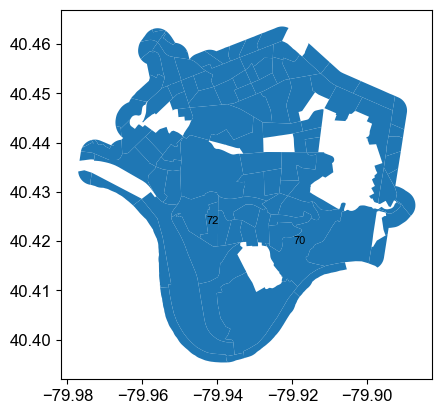

,org_geo,org_idx,pred,total_eligible,runs,has_bikeshare,less_than_1,between_1_2
61,1516001,72,7.639189,54,1,0,6.486390,40.530626
90,1414004,70,11.602291,111,13,0,6.620059,7.878928


In [29]:
selected = [70,72]
selected_pop = gdf_pop[gdf_pop['org_idx'].isin(selected)]
selected_pop['coords'] = selected_pop['geometry'].apply(lambda x: x.representative_point().coords[:])
selected_pop['coords'] = [coords[0] for coords in selected_pop['coords']]
gdf_pop[~gdf_pop['org_idx'].isna()].plot();
for idx, row in selected_pop.iterrows(): #gdf_pop[~gdf_pop['org_idx'].isna()].iterrows():
    plt.annotate(text=int(row['org_idx']), xy=row['coords'], fontsize=8,
                 horizontalalignment='center');
plt.show();

df_merge[df_merge['org_idx'].isin([70,72])][['org_geo', 'org_idx', 'pred'] + covariates]

In [30]:
y_dict[23], y_dict[88], y_dict[14], y_dict[49]
modes = od_matrix['mode_subset'].apply(tuple).unique()
mode2idx = dict(zip(modes, range(len(modes))))
#od_matrix['mode_subset'] = od_matrix['mode_subset'].apply(tuple)
od_matrix['mode_idx'] = od_matrix['mode_subset'].apply(tuple).apply(lambda x: mode2idx[x])  # "map" function does not work

od_matrix['od'] = tuple(zip(od_matrix['org_idx'], od_matrix['dst_idx']))
od_matrix['odm'] = tuple(zip(od_matrix['org_idx'], od_matrix['dst_idx'], od_matrix['mode_idx']))
od_matrix['z'] = od_matrix['od'].map(z_dict)
od_matrix['x'] = od_matrix['odm'].map(x_dict)

org_23 = od_matrix[(od_matrix['org_idx'] == 23) & (od_matrix['expense_less_pt'].between(9.27,12.8)) & (od_matrix['access_indicator_time'] == 1) & ((od_matrix['mode_subset'] == "('tnc',)"))]
#org_23['new_x'] = (org_23['access_indicator_time'] == 1).astype(int) # &(org_23['mode_subset'] == "('sc',)")] #['opp_jobs_total'].sum() # ((org_23['mode_subset'].str.contains('sc', regex=False)) | (org_23['mode_subset'].str.contains('tnc', regex=False)))]
org_23['opp_jobs_total'].sum()

(0.0, 13.155937878809596, 0.0, 0.0)

6054.118807856594

In [31]:
df = od_matrix.copy()

num_opps_list = []
for i in np.arange(4, 13.75, 0.25):
    df['access_indicator_monetary'] = (df['expense_less_pt'] <= i).astype(int)
    df['opportunities'] = df['opp_jobs_total'] * df['access_indicator_time'] * df['access_indicator_monetary']
    co_test = df.groupby(['org_idx','dst_idx'])['opportunities'].max().reset_index().groupby('org_idx')['opportunities'].sum().reset_index().sort_values(by='opportunities', ascending=True)
    
    for org in selected:
        num_opps = co_test[co_test['org_idx'] == org]['opportunities'][org]
        num_opps_list.append((org,i,num_opps))

In [32]:
all_72 = [(entry[1],entry[2]) for entry in num_opps_list if entry[0] == 72]
all_70 = [(entry[1],entry[2]) for entry in num_opps_list if entry[0] == 70]
all_72.append((7.39, 4709.045))
all_70.append((12.5, 8193.38))
sub_jobs = {}
sub_jobs[72] = all_72
sub_jobs[70] = all_70

/tmp/ipykernel_16978/4108882099.py:30: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate(text='Allocated subsidy', xy=(7.39 - 0.02, 4709.045), xytext=(7.39 - 2, 4709.045), va='center', ha='center', fontsize=12, arrowprops=arrowprops, color='red')
/tmp/ipykernel_16978/4108882099.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate(text='Allocated subsidy', xy=(12.5 - 0.02, 8193.38), xytext=(12.5 - 2, 8193.38), va='center', ha='center', fontsize=12, arrowprops=arrowprops, color='red')


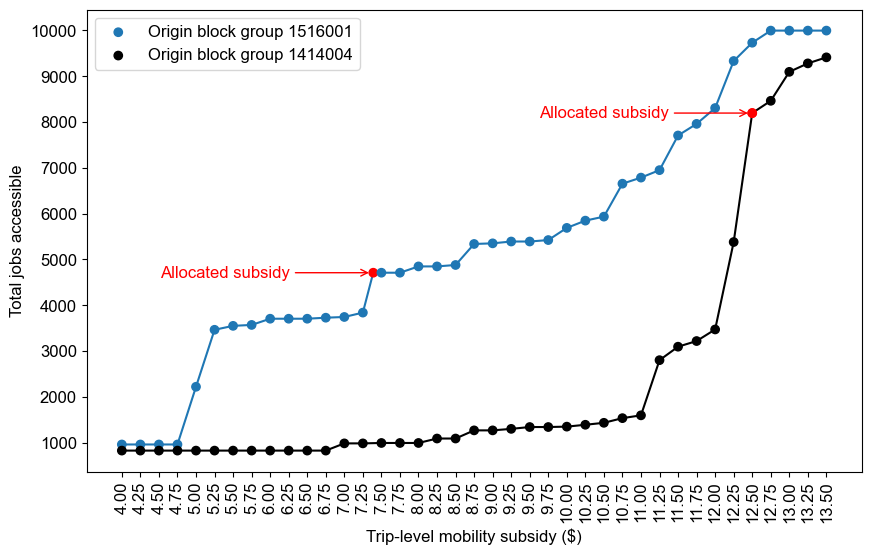

In [34]:
from matplotlib.ticker import FormatStrFormatter
colors = ['tab:blue', 'black']
labels = ['Origin block group 1516001', 'Origin block group 1414004']

fig, ax = plt.subplots(figsize=(10,6), sharey=True)
for idx, (org, points) in enumerate(sub_jobs.items()):
    sub, jobs = list(zip(*points))
    sub = list(sub)
    jobs = list(jobs)
    sub.sort()
    jobs.sort()
    xlabels = np.arange(4, 13.74, step=0.25)
    ax.set_xticks(ticks=xlabels, labels=xlabels, rotation=90) 
    ax.set_xticks(ticks=xlabels, labels=xlabels, rotation=90) 
    ax.set_xlabel('Trip-level mobility subsidy ($)')
    ax.set_xlabel('Trip-level mobility subsidy ($)')
    ax.set_yticks(np.arange(0, 110000, step=1000)) 
    ax.set_ylabel('Total jobs accessible')
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    size = 30
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1, color='red')
    # Highlight specific points in red
    highlight_x = 7.39 if idx == 0 else 12.5  # 7.39 for the blue line, 12.5 for the black line
    color = [colors[idx] if s != highlight_x else 'red' for s in sub]
    
    ax.plot(sub, jobs, color=colors[idx], zorder=1)
    ax.scatter(x=sub, y=jobs, color=color, label=labels[idx], zorder=2)

ax.annotate(text='Allocated subsidy', xy=(7.39 - 0.02, 4709.045), xytext=(7.39 - 2, 4709.045), va='center', ha='center', fontsize=12, arrowprops=arrowprops, color='red')
ax.annotate(text='Allocated subsidy', xy=(12.5 - 0.02, 8193.38), xytext=(12.5 - 2, 8193.38), va='center', ha='center', fontsize=12, arrowprops=arrowprops, color='red')
ax.legend()
plt.show();


In [23]:
df = df_cost_matrix.copy()
i = 9.27
df['access_indicator_monetary'] = (df['expense_less_pt'].between(6, 8.50)).astype(int)
df['opportunities'] = df['opp_jobs_total'] * df['access_indicator_time'] * df['access_indicator_monetary']
df[(df['org_idx'] == 49) & (df['opportunities'] > 0)] # & (df['access_indicator_monetary'] > 0)].sort_values(by=['opp_jobs_total'], ascending=False).tail(10)

,org,dst,mode_subset,travel_time,expense,expense_less_pt,gtc,org_idx,dst_idx,access_indicator_time,access_indicator_monetary,opp_jobs_total,opportunities,mode_idx,od,odm,z,x
29031,org1517002,dst1408001,"('sc',)",1167.644166,7.649216,7.649216,14.546300,49,13,1,1,11.516607,11.516607,2,"(49, 13)","(49, 13, 2)",1,1
29040,org1517002,dst0409003,"('sc',)",1224.331347,7.620273,7.620273,15.490464,49,7,1,1,3.508505,3.508505,2,"(49, 7)","(49, 7, 2)",1,1
29042,org1517002,dst0409002,"('sc',)",1227.182149,7.933646,7.933646,15.841716,49,5,1,1,8.443668,8.443668,2,"(49, 5)","(49, 5, 2)",1,1
29048,org1517002,dst1414002,"('sc',)",1147.018480,7.423424,7.423424,14.786008,49,83,1,1,0.521750,0.521750,2,"(49, 83)","(49, 83, 2)",1,1
29074,org1517002,dst0406001,"('sc',)",1275.571733,8.381230,8.381230,16.694202,49,77,1,1,0.354887,0.354887,2,"(49, 77)","(49, 77, 2)",1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176306,org1517002,dst0409002,"('pt', 'tnc', 'sc', 'bs')",1079.909315,6.976373,6.976373,14.159674,49,5,1,1,8.443668,8.443668,14,"(49, 5)","(49, 5, 14)",1,1
176312,org1517002,dst1414002,"('pt', 'tnc', 'sc', 'bs')",1024.873842,6.629484,6.629484,13.418179,49,83,1,1,0.521750,0.521750,14,"(49, 83)","(49, 83, 14)",1,1
176335,org1517002,dst1609002,"('pt', 'tnc', 'sc', 'bs')",1610.148346,7.546823,7.546823,17.819424,49,62,1,1,480.558464,480.558464,14,"(49, 62)","(49, 62, 14)",1,1
176357,org1517002,dst1408003,"('pt', 'tnc', 'sc', 'bs')",973.812673,6.214328,6.214328,12.087202,49,44,1,1,12.717111,12.717111,14,"(49, 44)","(49, 44, 14)",1,1


In [22]:
df_results.head()

,org_idx,daily_allowance,total_jobs,transit_jobs,job_diff,org_geo_x,geometry_x,total_eligible_x,pop_opp,group,GEOID,x,y,total_eligible_y,geometry_y,org_geo_y,org
0,4,0.0,8423.728374,8328.628139,9.510023e+01,0404001,"POLYGON ((-79.95028 40.44682, -79.94989 40.446...",41,3.453729e+05,0,420030404001,-79.948448,40.445825,41,"POLYGON ((-79.95028 40.44682, -79.94989 40.446...",0404001,org0404001
1,39,0.0,5609.933947,5573.465800,3.646815e+01,0806002,"POLYGON ((-79.93687 40.45946, -79.93674 40.459...",15,8.414901e+04,0,420030806002,-79.939120,40.457793,15,"POLYGON ((-79.93687 40.45946, -79.93674 40.459...",0806002,org0806002
2,10,0.0,5516.927017,5516.927017,0.000000e+00,0409001,"POLYGON ((-79.97287 40.43653, -79.97284 40.436...",433,2.388829e+06,0,420030409001,-79.962693,40.435509,433,"POLYGON ((-79.97287 40.43653, -79.97284 40.436...",0409001,org0409001
3,47,0.0,5734.503622,5153.323798,5.811798e+02,1401002,"POLYGON ((-79.94202 40.44069, -79.94186 40.441...",55,3.153977e+05,0,420031401002,-79.932920,40.440632,55,"POLYGON ((-79.94202 40.44069, -79.94186 40.441...",1401002,org1401002
4,1,0.0,5001.060536,5001.060536,-1.818989e-12,0305002,"POLYGON ((-79.97572 40.43921, -79.97537 40.439...",158,7.901676e+05,0,420030305002,-79.975778,40.439118,158,"POLYGON ((-79.97572 40.43921, -79.97537 40.439...",0305002,org0305002


In [26]:
N = 40
b = 260
MONTHLY_TRANSIT_PASS = 97.50
b_star = b - MONTHLY_TRANSIT_PASS
df_equal = od_matrix.copy()
df_equal['access_indicator_monetary'] = (df_equal['expense_less_pt'].between(0, b_star/N)).astype(int)
df_equal['opportunities'] = df_equal['opp_jobs_total'] * df_equal['access_indicator_time'] * df_equal['access_indicator_monetary']
cumulative_opps_equal = df_equal.groupby(['org_idx','dst_idx'])['opportunities'].max().reset_index().groupby('org_idx')['opportunities'].sum().reset_index().sort_values(by='opportunities', ascending=True)
#cumulative_opps_equal.head()
equal_subsidy = pd.merge(cumulative_opps_no_sub, cumulative_opps_equal, how='inner', on='org_idx')
equal_subsidy['job_diff'] = equal_subsidy['opportunities'] - equal_subsidy['transit_jobs']

gdf_pop = gdf_pop[~gdf_pop['org_idx'].isna()]
gdf_pop_nonzero = gdf_pop[gdf_pop['total_eligible'] > 0]
gdf_pop_nonzero['org_idx'] = gdf_pop_nonzero['org_idx'].astype(int)
equal_subsidy = pd.merge(equal_subsidy, gdf_pop_nonzero, how='inner', on='org_idx')
equal_subsidy['pop_opp'] = equal_subsidy['total_eligible'] * equal_subsidy['opportunities']

df_results = pd.merge(df_results, gdf_pop_nonzero, how='inner', on='org_idx')

# Comparison:
df_results['pop_opp'] = df_results['total_eligible'] * df_results['total_jobs']

equal_subsidy['pop_opp'].sum() / df_results['pop_opp'].sum()  
equal_subsidy['opportunities'].min() / equal_subsidy['opportunities'].max()  # level of fairness
equal_subsidy['opportunities'].sum() / df_results['total_jobs'].sum()  # total jobs reachable

weight_counts = {
    "Jobs accessible by transit": equal_subsidy['transit_jobs'],
    "Additional jobs accessed with subsidy": equal_subsidy['job_diff'],
}
width = 0.5

fig, ax = plt.subplots(figsize=(10,6))
#x = equal_subsidy['org_geo'].tolist()
x = equal_subsidy['org_geo'].astype(str).tolist()
bottom = np.zeros(len(x))

cmap = {"Jobs accessible by transit": 'silver', "Additional jobs accessed with subsidy": 'tab:blue'}
for boolean, weight_count in weight_counts.items():
    p = ax.bar(x, weight_count, width, label=boolean, bottom=bottom, color=cmap[boolean])
    bottom += weight_count

#ax.set_title("Equal Subsidy Allocation")
ax.legend(loc="upper right")
ax.set_xlabel('Census block group')
ax.set_ylabel('Total jobs accessible')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
yticks = np.arange(0,10000,1000)
ax.set_yticks(yticks)
ax.set_xlim(-1, len(x))
plt.tight_layout()
ax.set_xticks([])
#ax.set_xticklabels(x, fontsize=6)
plt.show();



KeyError: 'total_eligible'